
Simple tutorial based on a more complete one: https://github.com/desihub/tutorials/blob/main/01_getting_started/06_PublicDatabaseAccess.ipynb$0

This is not necesarly the best way to access a large volume of data, but should be simple enough for the PCA ejercise.

Make sure to work in a clean enviromen and have Spacl and astrodatalab installed

pip install astro-datalab

pip install sparclclient

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.convolution import convolve, Gaussian1DKernel

## DataLab and SPARCL related modules
from sparcl.client import SparclClient
from dl import queryClient as qc

from sklearn.decomposition import PCA

In [2]:
## Instantiate SPARCLClient
client = SparclClient()

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


In [52]:
# Write a query to select the primary spectrum in the Main survey for .1% of the sample
# (see detailed information below)
query = """
        SELECT zp.targetid, zp.z, 3600/(1+zp.z) as begin,  9824.000000000524/(1+zp.z) as end, 3600*(1-(1/(1+zp.z))) as shift
        FROM desi_dr1.zpix AS zp
        WHERE (zp.survey='main') AND (zp.spectype ='GALAXY') AND zp.main_primary AND (zp.random_id BETWEEN 0. AND 0.1) AND zp.z>0.5 AND zp.z<0.7 AND zp.zwarn=0
        """ 

## Information about the query
## 
## Selected columns --
##   targetid, survey, program -- unique identifiers for a given spectrum
##   z -- spectroscopic redshift of the target
##   zwarn -- encoded information regarding the redshift (zwarn = 0 is good)
##   spectype -- Spectral type of the target: STAR | GALAXY | QSO
## Constraints (WHERE statement) --
##   survey: selecting main survey only
##   main_primary: keeping only the best spectrum in Main (removes possible multiples)
##   random_id: selects a slice of 1% of the sample (0-1 out of 100)

In [53]:
zpix_cat = qc.query(sql = query, fmt = 'table')
zpix_cat

targetid,z,begin,end,shift
int64,float64,float64,float64,float64
39628381255371918,0.6262485043979544,2213.6838190868857,6040.897177419646,1386.3161809131143
39627677266613138,0.5210514759316032,2366.783805127369,6458.690028214586,1233.2161948726311
39628403124472002,0.5238726383440784,2362.4021518700883,6446.73298332583,1237.5978481299114
39633015504111906,0.6961830049570344,2122.4124929203563,5791.827869569636,1477.587507079644
39633054381117050,0.6458085529614341,2187.374706202756,5969.102531593617,1412.625293797244
39627773530082111,0.6218989554385962,2219.6203949255787,6057.097433263902,1380.3796050744213
39633140280461695,0.6678450300913178,2158.4739199677883,5890.235497156856,1441.5260800322117
39628043592925930,0.5373276474777278,2341.7259202398855,6390.309844566073,1258.2740797601148
39628321096468821,0.6552849871014564,2174.852081697366,5934.929680721128,1425.1479183026343


In [54]:
targetid=zpix_cat['targetid'].data.tolist()
# Number of spectra 
n =len(targetid)
n

986

In [63]:
#Definiendo limites de las nuevas frecuencias
begin_lam = zpix_cat['begin'].max()
end_lam = zpix_cat['end'].min()
wavelenght = np.arange(begin_lam, end_lam, 0.8)
wavelenght


array([2399.71530279, 2400.51530279, 2401.31530279, ..., 5778.1153028 ,
       5778.9153028 , 5779.7153028 ], shape=(4226,))

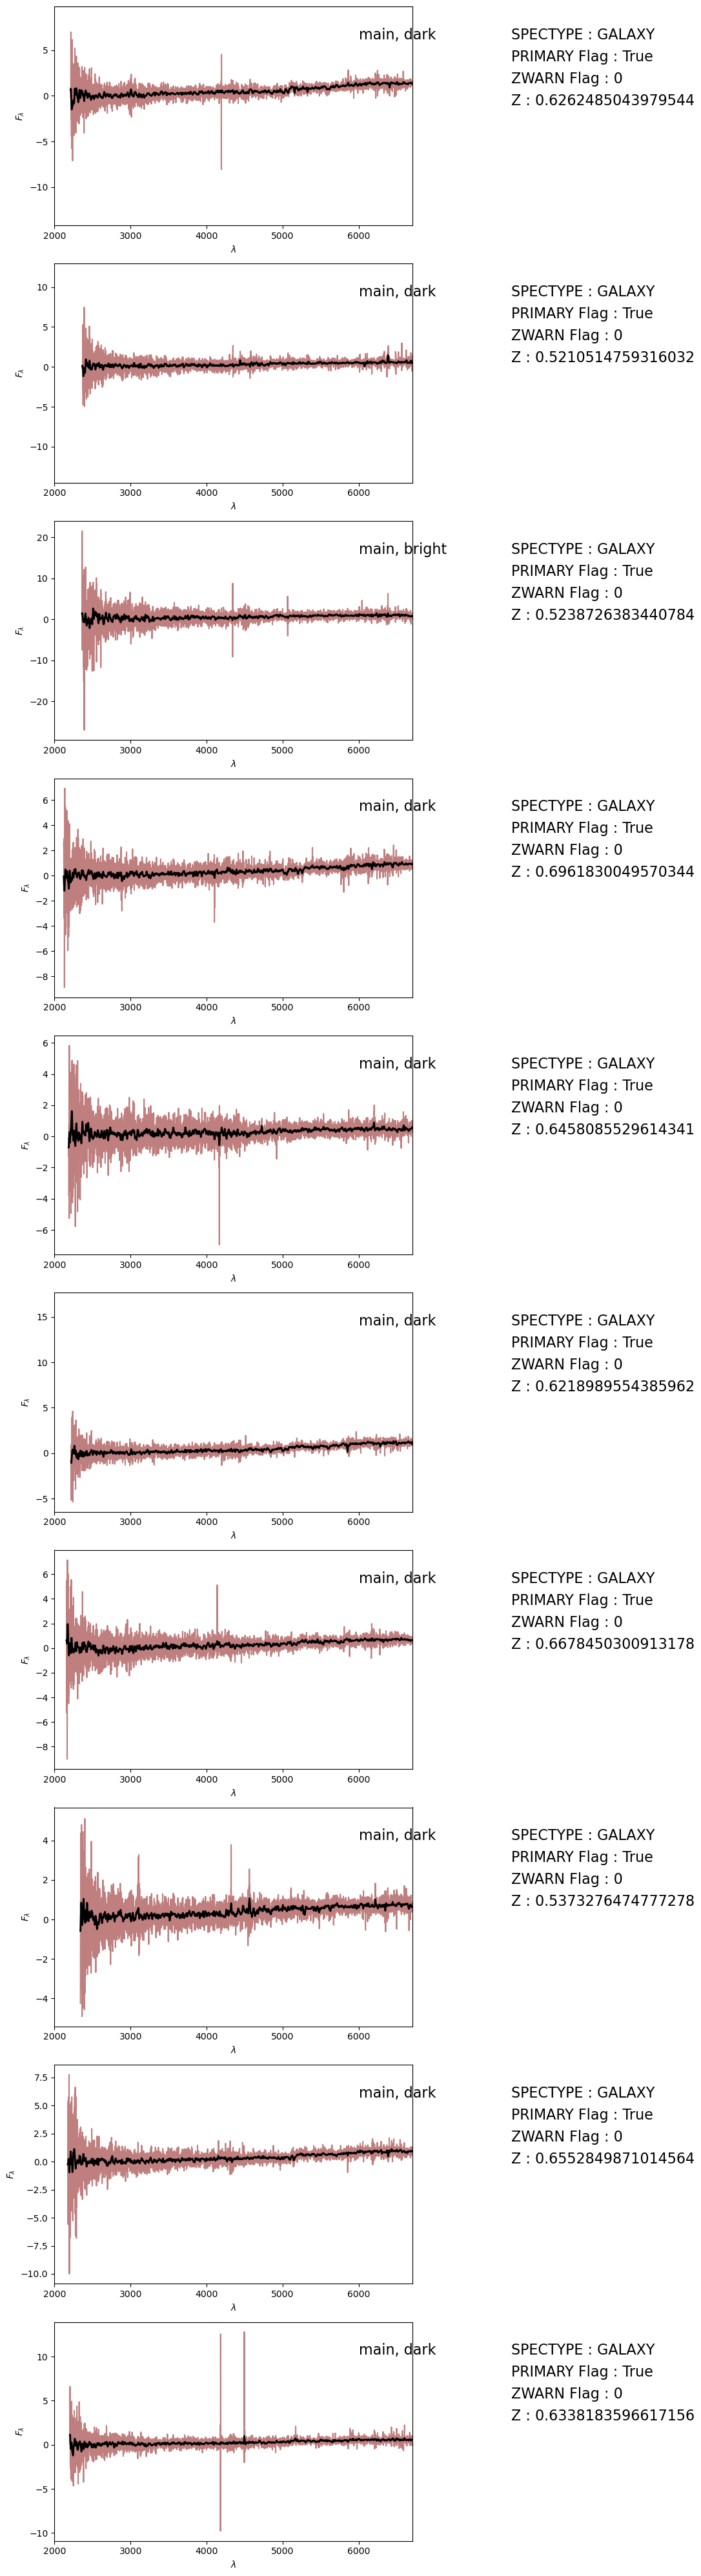

In [57]:
# Number of spectra to plot
n =10 #len(targetid)

fig, ax = plt.subplots(n, 1, figsize = (12,(4*n)))

for jj in range(n):
    inc = ['specid', 'redshift', 'flux', 'wavelength', 'spectype', 'specprimary', 'survey', 'program', 'targetid', 'redshift_warning']
    res = client.retrieve_by_specid(specid_list = [targetid[jj]],
                                include = inc,
                                dataset_list = ['DESI-DR1'])
    records = res.records
    survey = records[0].survey
    program = records[0].program
    spectype = records[0].spectype
    primary_flag = records[0].specprimary
    zwarn_flag = records[0].redshift_warning
    redshift = records[0].redshift

    shift = zpix_cat['shift'].data.tolist()

    lam = records[0].wavelength - shift[jj]
    flam = records[0].flux
    
    # Plot the combined spectrum in maroon
    ax[jj].plot(lam, flam, color = 'maroon', alpha = 0.5)
    # Over-plotting smoothed spectra 
    ax[jj].plot(lam, convolve(flam, Gaussian1DKernel(5)), color = 'k', lw = 2.0)
    ax[jj].set(xlim = [2000, 6700], xlabel = r'$\lambda$', ylabel = r'$F_{\lambda}$')
    trans = ax[jj].get_xaxis_transform()
    ax[jj].annotate(f'{survey}, {program}', xy = (6000, 0.85), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'SPECTYPE : {spectype}', xy = (8000, 0.85), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'PRIMARY Flag : {primary_flag}', xy = (8000, 0.75), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'ZWARN Flag : {zwarn_flag}', xy = (8000, 0.65), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'Z : {redshift }', xy = (8000, 0.55), xycoords = trans, fontsize = 16)
    
plt.tight_layout()

In [56]:
lam

array([2203.42731413, 2204.22731413, 2205.02731413, ..., 8425.82731413,
       8426.62731413, 8427.42731413], shape=(7781,))

In [15]:
3600 + 0.8*7780

9824.0

In [ ]:
3600.0 9824.000000000524